<a href="https://colab.research.google.com/github/TejashwiniByrappa/Tejashwini-landing-page/blob/main/car_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Car Dataset generated successfully!
Dataset Shape: (2000, 8)
   Original_Price  Car_Age  Kms_Driven Fuel_Type Seller_Type Transmission  \
0           23.73       12    123156.0    Diesel      Dealer    Automatic   
1           47.93        7    148178.0    Diesel      Dealer    Automatic   
2           38.74        3     19295.0    Petrol  Individual       Manual   
3           33.14        7     94171.0    Petrol  Individual       Manual   
4           14.55       12    216721.0    Diesel  Individual    Automatic   

   Engine_Size  Selling_Price  
0          1.8          10.57  
1          3.0          27.07  
2          3.0          26.19  
3          1.5          16.04  
4          1.8           2.80  


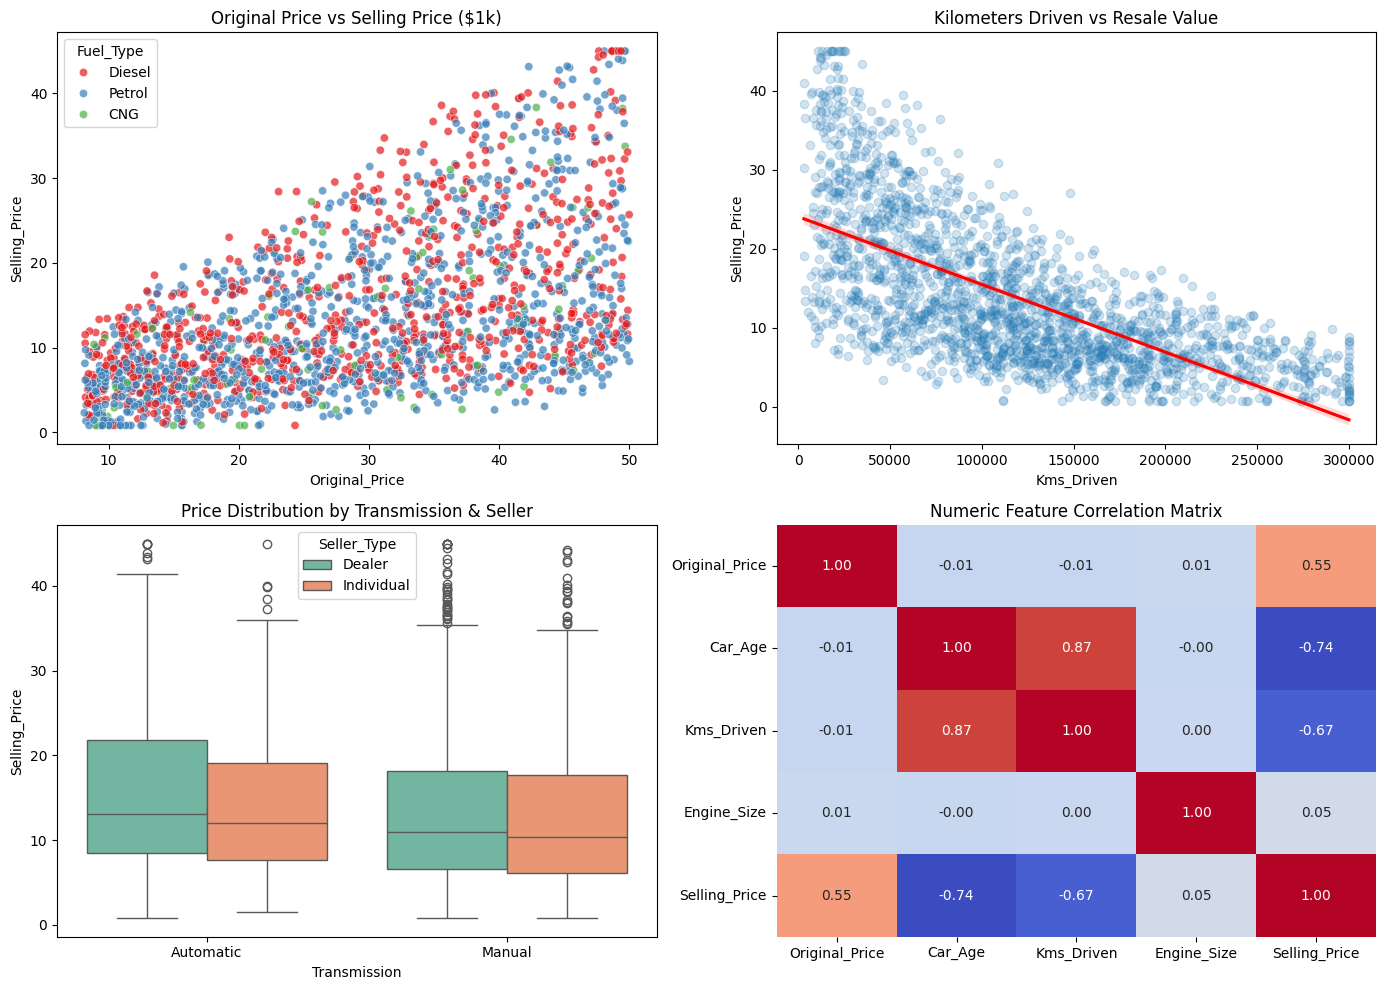

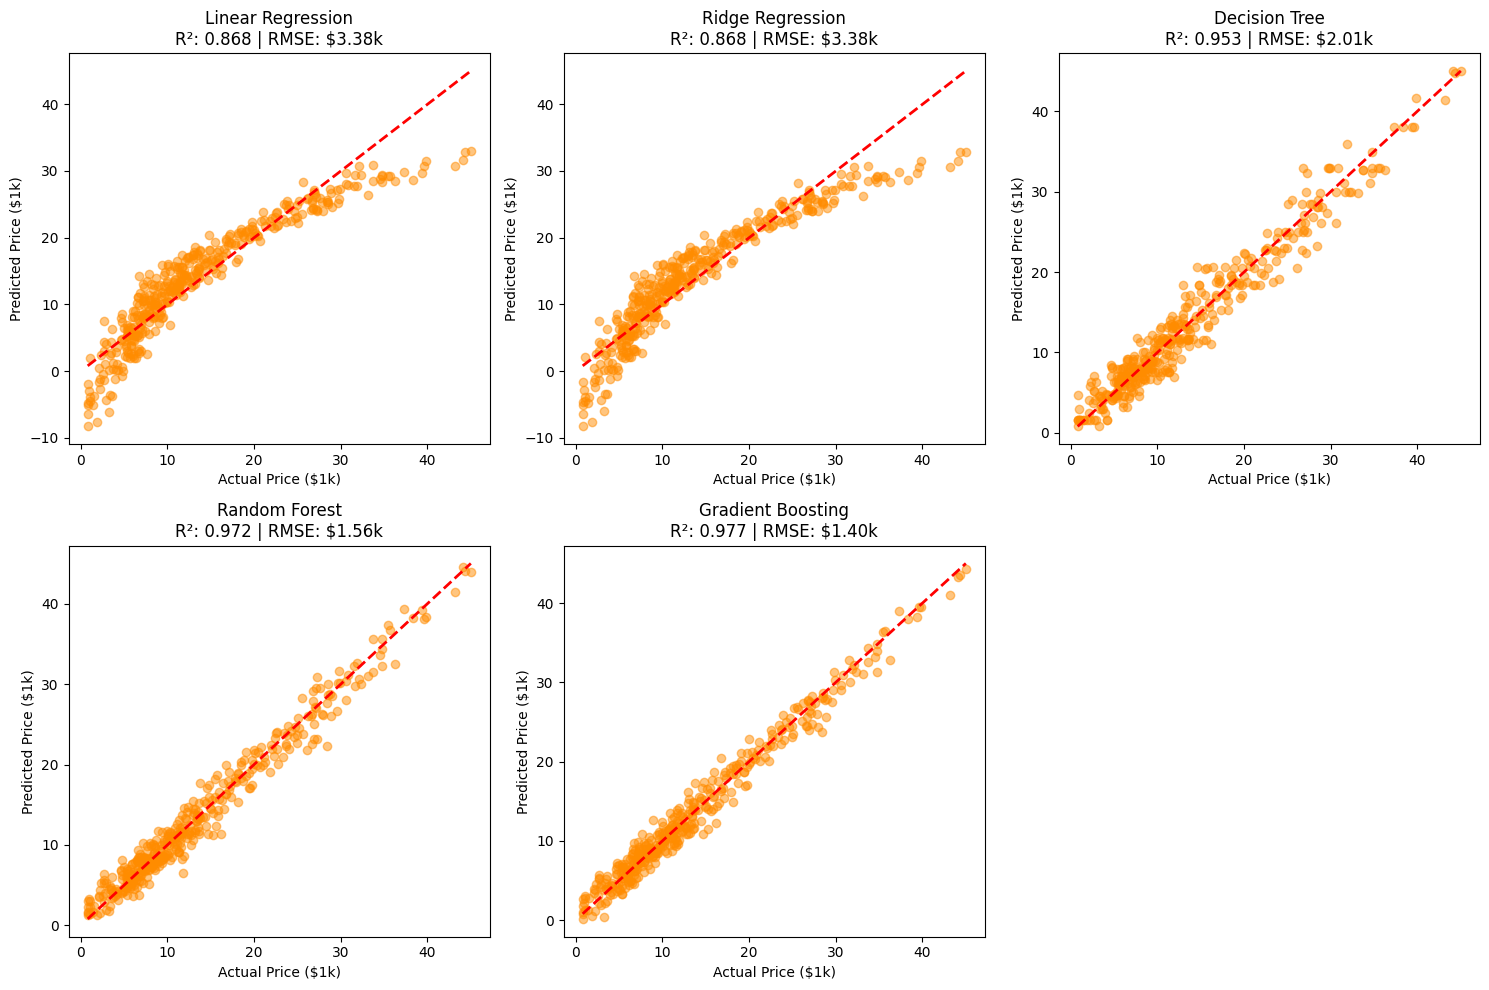

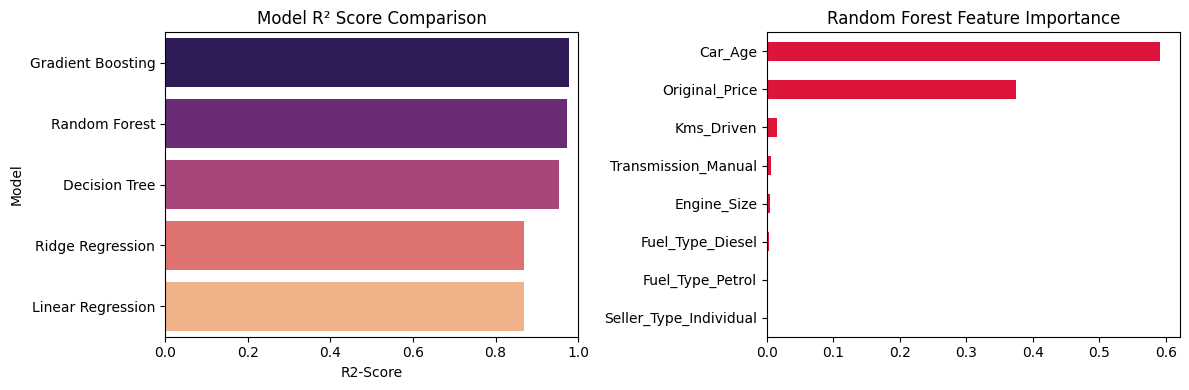


=== CAR PRICE PREDICTION PERFORMANCE RANKING ===
            Model  R2-Score  MAE ($1k)  RMSE ($1k)
Gradient Boosting  0.977388   1.108202    1.400291
    Random Forest  0.971846   1.221132    1.562485
    Decision Tree  0.953263   1.573800    2.013134
 Ridge Regression  0.867919   2.612888    3.384269
Linear Regression  0.867907   2.614417    3.384422


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.simplefilter(action='ignore', category=FutureWarning)

# ==========================================
# 1. GENERATE REALISTIC CAR PRICING DATASET
# ==========================================
np.random.seed(42)
n_samples = 2000

# Feature Generation
original_price = np.random.uniform(8.0, 50.0, n_samples).round(2)  # Original MSRP ($1k)
car_age = np.random.randint(1, 16, n_samples)                       # Age in years (1 to 15)
kms_driven = (car_age * np.random.uniform(8000, 22000, n_samples) + np.random.normal(0, 5000, n_samples)).clip(3000, 300000).round(0)
fuel_type = np.random.choice(['Petrol', 'Diesel', 'CNG'], size=n_samples, p=[0.55, 0.40, 0.05])
seller_type = np.random.choice(['Dealer', 'Individual'], size=n_samples, p=[0.65, 0.35])
transmission = np.random.choice(['Manual', 'Automatic'], size=n_samples, p=[0.70, 0.30])
engine_size = np.random.choice([1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0], size=n_samples, p=[0.15, 0.25, 0.30, 0.15, 0.08, 0.05, 0.02])

# Price target ($1k) computed using domain depreciation & pricing logic
depreciation_factor = (0.88 ** car_age)  # ~12% annual depreciation
selling_price = (
    original_price * depreciation_factor
    - (kms_driven / 100000) * 1.2
    + (fuel_type == 'Diesel') * 1.5
    + (transmission == 'Automatic') * 2.0
    + (seller_type == 'Dealer') * 0.8
    + engine_size * 0.9
    + np.random.normal(0, 1.2, n_samples)
).clip(0.8, 45.0).round(2)

df = pd.DataFrame({
    'Original_Price': original_price,
    'Car_Age': car_age,
    'Kms_Driven': kms_driven,
    'Fuel_Type': fuel_type,
    'Seller_Type': seller_type,
    'Transmission': transmission,
    'Engine_Size': engine_size,
    'Selling_Price': selling_price
})

print("Car Dataset generated successfully!")
print(f"Dataset Shape: {df.shape}")
print(df.head())


# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
plt.figure(figsize=(14, 10))

# Graph 1: Original Price vs Selling Price by Fuel Type
plt.subplot(2, 2, 1)
sns.scatterplot(x="Original_Price", y="Selling_Price", data=df, hue="Fuel_Type", palette="Set1", alpha=0.7)
plt.title("Original Price vs Selling Price ($1k)")

# Graph 2: Kilometers Driven vs Selling Price Trend
plt.subplot(2, 2, 2)
sns.regplot(x="Kms_Driven", y="Selling_Price", data=df, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title("Kilometers Driven vs Resale Value")

# Graph 3: Selling Price by Transmission & Seller Type
plt.subplot(2, 2, 3)
sns.boxplot(x="Transmission", y="Selling_Price", data=df, hue="Seller_Type", palette="Set2")
plt.title("Price Distribution by Transmission & Seller")

# Graph 4: Correlation Heatmap (Numeric Columns)
plt.subplot(2, 2, 4)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=False)
plt.title("Numeric Feature Correlation Matrix")

plt.tight_layout()
plt.show()


# ==========================================
# 3. PREPROCESSING & FEATURE ENCODING
# ==========================================
X = df.drop(columns=["Selling_Price"])
y = df["Selling_Price"]

# One-hot encode categorical features ('Fuel_Type', 'Seller_Type', 'Transmission')
X_encoded = pd.get_dummies(X, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==========================================
# 4. MODEL TRAINING & REGRESSION EVALUATION
# ==========================================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=8),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "R2-Score": r2,
        "MAE ($1k)": mae,
        "RMSE ($1k)": rmse
    })

    # Plot Actual vs Predicted Resale Prices
    axes[idx].scatter(y_test, y_pred, alpha=0.5, color='darkorange')
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[idx].set_title(f"{name}\nR²: {r2:.3f} | RMSE: ${rmse:.2f}k")
    axes[idx].set_xlabel("Actual Price ($1k)")
    axes[idx].set_ylabel("Predicted Price ($1k)")

axes[5].axis("off")
plt.tight_layout()
plt.show()


# ==========================================
# 5. MODEL RANKING & FEATURE IMPORTANCE
# ==========================================
results_df = pd.DataFrame(results).sort_values(by="R2-Score", ascending=False)

plt.figure(figsize=(12, 4))

# Chart 1: R2-Score Comparison
plt.subplot(1, 2, 1)
sns.barplot(x="R2-Score", y="Model", data=results_df, hue="Model", palette="magma", legend=False)
plt.title("Model R² Score Comparison")
plt.xlim(0, 1)

# Chart 2: Feature Importance from Random Forest
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns).sort_values(ascending=True)

plt.subplot(1, 2, 2)
importances.plot(kind="barh", color="crimson")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

print("\n=== CAR PRICE PREDICTION PERFORMANCE RANKING ===")
print(results_df.to_string(index=False))